# Notebook 01 - EDA

## Can we trust this data enough to build a regulatory model from it?

<p> <b>Why it matters:</b> A credit risk model built on untrustworthy data does not just produce wrong predictions — it produces systematically wrong predictions in specific directions. If missing income values are not treated correctly, the model learns that people with missing income are average risk. They are not. If sentinel values are left in the delinquency columns, the model learns that being seriously delinquent 98 times predicts default. It does not — it predicts that someone forgot to fill in a form. Every data quality error is a direction in which the model's predictions will be reliably wrong.</p>
For a bank this means provisions are wrong. Capital is wrong. Regulatory submissions are wrong. And unlike a recommendation engine where a bad prediction means someone watches a movie they do not like — a wrong PD estimate means a bank either holds too much capital and destroys shareholder value or holds too little and fails when defaults materialise.

In [98]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [99]:
# Open dataset

data_df = pd.read_csv('../data/data.csv')
print(data_df.head())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [100]:
# Drop unamed and define target data (SeriousDlqin2yrs) and drop it

X = data_df.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'])
y = data_df['SeriousDlqin2yrs']

print(X.describe())
print(f'Defaulters distribution: {y.mean()}')

       RevolvingUtilizationOfUnsecuredLines            age  \
count                         150000.000000  150000.000000   
mean                               6.048438      52.295207   
std                              249.755371      14.771866   
min                                0.000000       0.000000   
25%                                0.029867      41.000000   
50%                                0.154181      52.000000   
75%                                0.559046      63.000000   
max                            50708.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         150000.000000  150000.000000   1.202690e+05   
mean                               0.421033     353.005076   6.670221e+03   
std                                4.192781    2037.818523   1.438467e+04   
min                                0.000000       0.000000   0.000000e+00   
25%                                0.000000       0.1750

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Train-Test Split — The First and Most Important Step

Before any analysis, any cleaning, any transformation — we split the data.

This is non-negotiable. Every parameter we calculate from this point forward
— medians, percentile caps, WoE values, model coefficients — is calculated
on the training set only and then applied to the test set using those
training-derived values.

The test set is now sealed. It will not be touched again until the final
model evaluation in Notebook 04.

**Why stratify=y?**
With a 6.68% default rate, unstratified random splitting could produce
materially different default rates in train and test by chance. Stratification
guarantees both sets have identical default rates — critical for unbiased
model evaluation.

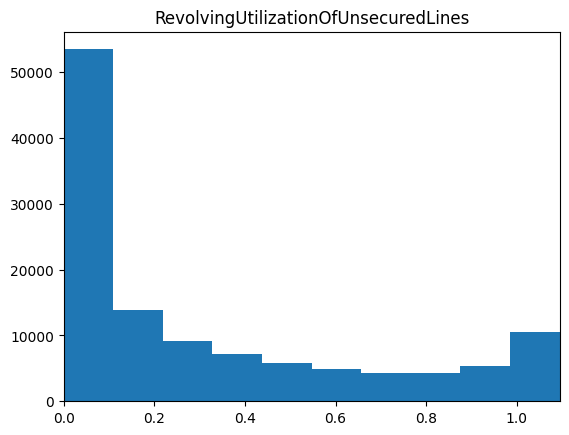

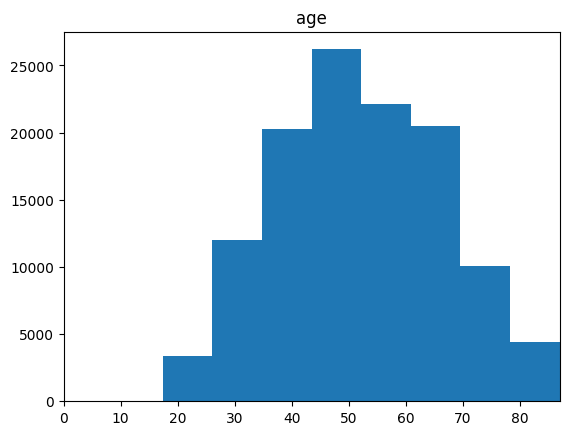

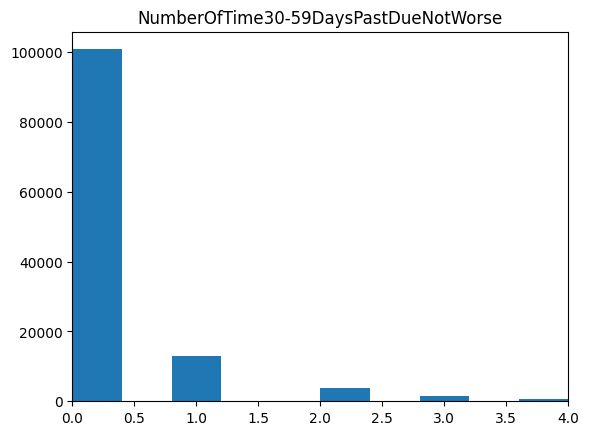

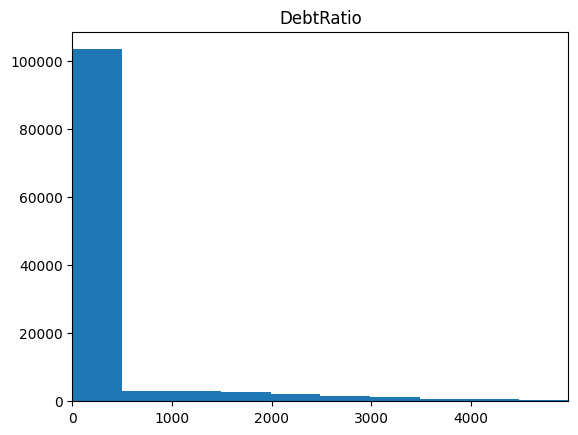

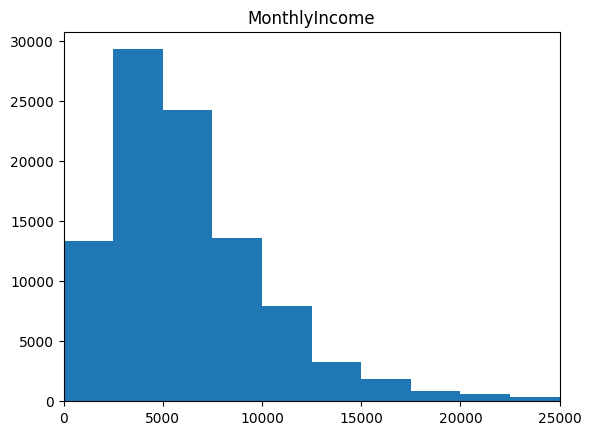

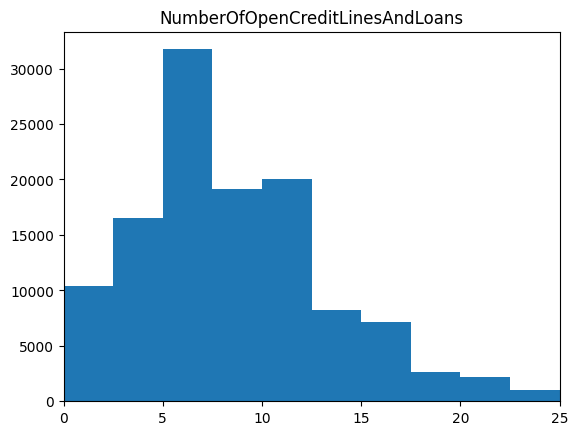

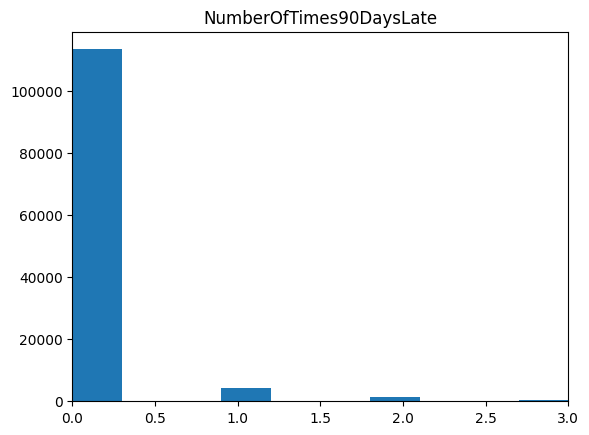

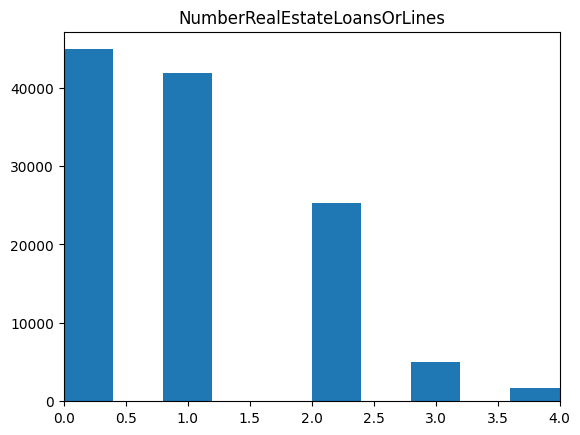

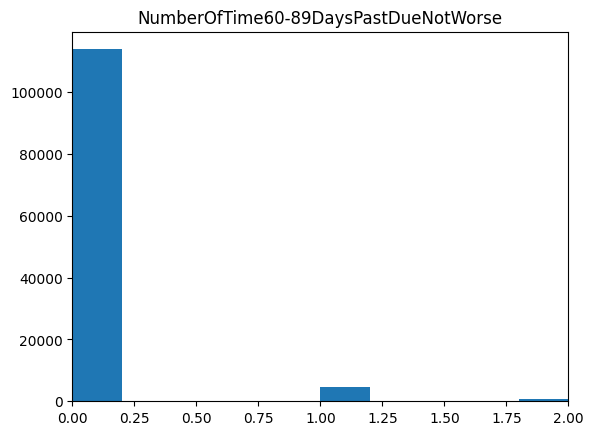

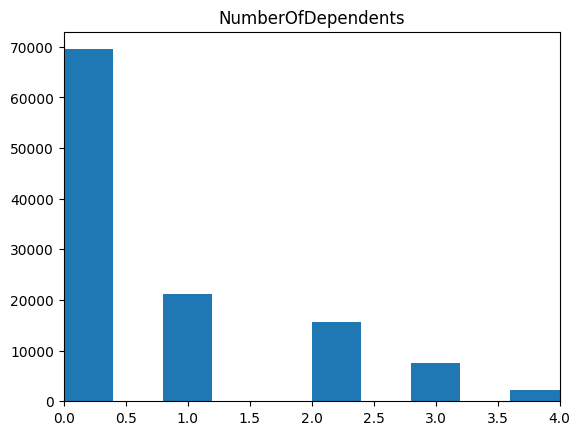

In [102]:
# EDA specific features

columns = X_train.columns
for i in columns:
    p99 = np.nanpercentile(X_train[i], 99)
    data_to_plot = X_train[i][X_train[i] <= p99]
    plt.hist(data_to_plot, bins=10)
    plt.xlim(0,p99)
    plt.title(i)
    plt.show()

In [103]:
# Explore Outlier and Missing Values
columns = X_train.columns
for i in columns:
    print(f'The 99 percentile of {i} is: {np.nanpercentile(X_train[i], 99)}')
    print(f'The 99.9 percentile of {i} is: {np.nanpercentile(X_train[i], 99.9)}')
    print(f'Missing values of {i}: {X_train[i].isna().sum()}')


The 99 percentile of RevolvingUtilizationOfUnsecuredLines is: 1.0944386634299974
The 99.9 percentile of RevolvingUtilizationOfUnsecuredLines is: 1655.0040000000736
Missing values of RevolvingUtilizationOfUnsecuredLines: 0
The 99 percentile of age is: 87.0
The 99.9 percentile of age is: 93.0010000000184
Missing values of age: 0
The 99 percentile of NumberOfTime30-59DaysPastDueNotWorse is: 4.0
The 99.9 percentile of NumberOfTime30-59DaysPastDueNotWorse is: 98.0
Missing values of NumberOfTime30-59DaysPastDueNotWorse: 0
The 99 percentile of DebtRatio is: 4977.0
The 99.9 percentile of DebtRatio is: 10613.074000001361
Missing values of DebtRatio: 0
The 99 percentile of MonthlyIncome is: 25000.0
The 99.9 percentile of MonthlyIncome is: 77764.7760000049
Missing values of MonthlyIncome: 23675
The 99 percentile of NumberOfOpenCreditLinesAndLoans is: 25.0
The 99.9 percentile of NumberOfOpenCreditLinesAndLoans is: 35.0
Missing values of NumberOfOpenCreditLinesAndLoans: 0
The 99 percentile of Numbe

In [104]:
print(X_train['NumberOfTimes90DaysLate'].value_counts().sort_index(ascending=False).head(26))

NumberOfTimes90DaysLate
98       212
96         2
17         1
15         2
14         2
13         3
12         1
11         3
10         7
9         13
8         15
7         29
6         62
5        100
4        238
3        530
2       1256
1       4230
0     113294
Name: count, dtype: int64


In [105]:
# RevolvingUtilizationOfUnsecuredLines - missing values: 0
# Decision: Apply Winsorization to control outliers

# Step 1 — calculate the cap on non-missing values
cap = np.nanpercentile(X_train['RevolvingUtilizationOfUnsecuredLines'], 99)

# Step 2 — replace values above cap with the cap value
X_train['RevolvingUtilizationOfUnsecuredLines'] = X_train['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap)

print(f'The 99 percentile of RevolvingUtilizationOfUnsecuredLines is: {np.nanpercentile(X_train['RevolvingUtilizationOfUnsecuredLines'], 99)}')
print(f'The 99.9 percentile of RevolvingUtilizationOfUnsecuredLines is: {np.nanpercentile(X_train['RevolvingUtilizationOfUnsecuredLines'], 99.9)}')

The 99 percentile of RevolvingUtilizationOfUnsecuredLines is: 1.0944339991143
The 99.9 percentile of RevolvingUtilizationOfUnsecuredLines is: 1.0944386634299974


## MonthlyIncome — Three Problems, One Pipeline

MonthlyIncome has three distinct data quality problems that require treatment in strict order. Getting the order wrong produces subtly wrong results.

**Problem 1 — Near-zero implausible values.** Values between $1 and $99 per month exist in the data but are economically impossible for a US credit borrower. These are data entry errors — perhaps annual income entered as monthly, or a system default. They are replaced with NaN and treated as missing.

**Problem 2 — Extreme outliers.** The maximum value of $3,008,750 per month is technically possible but the gap between the 99th percentile ($25,000) and the maximum (120 times larger) suggests isolated data entry errors rather than genuine high earners. However rather than Winsorizing we apply a log transformation instead — which compresses the entire right tail naturally without requiring an arbitrary cap.

**Problem 3 — Missing values.** 29,731 observations — 19.8% of the dataset — have no income recorded. After log transformation we impute with the median of the log-transformed values. This is more appropriate than imputing in the raw scale and then transforming, because the median of log(income) is the log of the geometric mean — the correct central tendency for a lognormal distribution.

The log transformation log(1+x) serves three purposes simultaneously: it compresses the right tail, converts the approximately lognormal distribution toward normality, and handles zero values safely since log(1+0) = 0.

In [106]:
# Save raw MonthlyIncome BEFORE any cleaning touches it
# Income_missing flag must be created from original values
# This cell must run before any MonthlyIncome transformation
raw_income_train = X_train['MonthlyIncome'].copy()
raw_income_test = X_test['MonthlyIncome'].copy()

print(f"Raw income — missing in train: {raw_income_train.isna().sum():,}")
print(f"Raw income — below $100 in train: {(raw_income_train < 100).sum():,}")
print(f"Raw income — total flagged: {(raw_income_train.isna() | (raw_income_train < 100)).sum():,}")

Raw income — missing in train: 23,675
Raw income — below $100 in train: 1,851
Raw income — total flagged: 25,526


In [107]:
# MonthlyIncome - missing values: 29731
# Step 1 — Replace implausible near-zero values with NaN
income_threshold = 100
implausible_mask = (X_train['MonthlyIncome'] > 0) & (X_train['MonthlyIncome'] < income_threshold)
n_implausible = implausible_mask.sum()
X_train.loc[implausible_mask, 'MonthlyIncome'] = np.nan
print(f"Replaced {n_implausible:,} implausible values (0 < income < {income_threshold})")

# Step 2 — Log transform BEFORE imputation
# Median of log-transformed values is the log of the geometric mean
# More appropriate than log(median) for a lognormal distribution
X_train['MonthlyIncome'] = np.log1p(X_train['MonthlyIncome'])

# Step 3 — Impute missing values with median of log-transformed values
n_missing = X_train['MonthlyIncome'].isna().sum()
log_median = X_train['MonthlyIncome'].median()
X_train['MonthlyIncome'] = X_train['MonthlyIncome'].fillna(log_median)
print(f"Imputed {n_missing:,} missing values with log-median: {log_median:.4f}")

# Apply same treatment to test set using TRAINING parameters
X_test.loc[
    (X_test['MonthlyIncome'] > 0) & (X_test['MonthlyIncome'] < income_threshold),
    'MonthlyIncome'
] = np.nan
X_test['MonthlyIncome'] = np.log1p(X_test['MonthlyIncome'])
X_test['MonthlyIncome'] = X_test['MonthlyIncome'].fillna(log_median)  # Training median

# Verify — values should now be in log scale approximately 4.6 to 10.1
print(f"\nMonthlyIncome after log transformation:")
print(f"  Min: {X_train['MonthlyIncome'].min():.4f}  (= log(1+0) for zero income)")
print(f"  Mean: {X_train['MonthlyIncome'].mean():.4f}")
print(f"  Max: {X_train['MonthlyIncome'].max():.4f}  (= log(1+{np.expm1(X_train['MonthlyIncome'].max()):,.0f}))")
print(f"  Missing: {X_train['MonthlyIncome'].isna().sum()}")

Replaced 529 implausible values (0 < income < 100)
Imputed 24,204 missing values with log-median: 8.5943

MonthlyIncome after log transformation:
  Min: 0.0000  (= log(1+0) for zero income)
  Mean: 8.4784
  Max: 14.9170  (= log(1+3,008,750))
  Missing: 0


In [108]:
# NumberOfDependents - missing values: 3924
# Decision: Input median since we are facing a right skewed distribution and median is less sensitive to outliers

# Input median to nan values
X_train['NumberOfDependents'] = X_train['NumberOfDependents'].fillna(X_train['NumberOfDependents'].median())

print(f'The 99 percentile of NumberOfDependents is: {np.nanpercentile(X_train['NumberOfDependents'], 99)}')
print(f'The 99.9 percentile of NumberOfDependents is: {np.nanpercentile(X_train['NumberOfDependents'], 99.9)}')

The 99 percentile of NumberOfDependents is: 4.0
The 99.9 percentile of NumberOfDependents is: 6.0


In [109]:
# NumberOfTime30-59DaysPastDueNotWorse - missing values: 0
# Decision: Fill sentinel values with na
# Decision 2: Input median since we are facing a right skewed distribution and median is less sensitive to outliers

# Check sentinel values
print(X_train['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index(ascending=False).head(20))
X_train['NumberOfTime30-59DaysPastDueNotWorse'] = X_train['NumberOfTime30-59DaysPastDueNotWorse'].replace([96, 98], np.nan)

# Input median to nan values
X_train['NumberOfTime30-59DaysPastDueNotWorse'] = X_train['NumberOfTime30-59DaysPastDueNotWorse'].fillna(X_train['NumberOfTime30-59DaysPastDueNotWorse'].median())

print(f'The 99 percentile of NumberOfTime30-59DaysPastDueNotWorse is: {np.nanpercentile(X_train['NumberOfTime30-59DaysPastDueNotWorse'], 99)}')
print(f'The 99.9 percentile of NumberOfTime30-59DaysPastDueNotWorse is: {np.nanpercentile(X_train['NumberOfTime30-59DaysPastDueNotWorse'], 99.9)}')

NumberOfTime30-59DaysPastDueNotWorse
98       212
96         2
13         1
12         2
11         1
10         4
9         10
8         21
7         44
6        108
5        266
4        581
3       1421
2       3689
1      12844
0     100794
Name: count, dtype: int64
The 99 percentile of NumberOfTime30-59DaysPastDueNotWorse is: 3.0
The 99.9 percentile of NumberOfTime30-59DaysPastDueNotWorse is: 6.0


In [110]:
# NumberOfTimes90DaysLate - missing values: 0
# Decision: Fill sentinel values with na
# Decision 2: Input median since we are facing a right skewed distribution and median is less sensitive to outliers

# Check sentinel values
print(X_train['NumberOfTimes90DaysLate'].value_counts().sort_index(ascending=False).head(20))
X_train['NumberOfTimes90DaysLate'] = X_train['NumberOfTimes90DaysLate'].replace([96, 98], np.nan)

# Input median to nan values
X_train['NumberOfTimes90DaysLate'] = X_train['NumberOfTimes90DaysLate'].fillna(X_train['NumberOfTimes90DaysLate'].median())

print(f'The 99 percentile of NumberOfTimes90DaysLate is: {np.nanpercentile(X_train['NumberOfTimes90DaysLate'], 99)}')
print(f'The 99.9 percentile of NumberOfTimes90DaysLate is: {np.nanpercentile(X_train['NumberOfTimes90DaysLate'], 99.9)}')

NumberOfTimes90DaysLate
98       212
96         2
17         1
15         2
14         2
13         3
12         1
11         3
10         7
9         13
8         15
7         29
6         62
5        100
4        238
3        530
2       1256
1       4230
0     113294
Name: count, dtype: int64
The 99 percentile of NumberOfTimes90DaysLate is: 2.0
The 99.9 percentile of NumberOfTimes90DaysLate is: 6.0


In [111]:
# NumberOfTime60-89DaysPastDueNotWorse - missing values: 0
# Decision: Fill sentinel values with na
# Decision 2: Input median since we are facing a right skewed distribution and median is less sensitive to outliers

# Check sentinel values
print(X_train['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index(ascending=False).head(20))
X_train['NumberOfTime60-89DaysPastDueNotWorse'] = X_train['NumberOfTime60-89DaysPastDueNotWorse'].replace([96, 98], np.nan)

# Input median to nan values
X_train['NumberOfTime60-89DaysPastDueNotWorse'] = X_train['NumberOfTime60-89DaysPastDueNotWorse'].fillna(X_train['NumberOfTime60-89DaysPastDueNotWorse'].median())

print(f'The 99 percentile of NumberOfTime60-89DaysPastDueNotWorse is: {np.nanpercentile(X_train['NumberOfTime60-89DaysPastDueNotWorse'], 99)}')
print(f'The 99.9 percentile of NumberOfTime60-89DaysPastDueNotWorse is: {np.nanpercentile(X_train['NumberOfTime60-89DaysPastDueNotWorse'], 99.9)}')

NumberOfTime60-89DaysPastDueNotWorse
98       212
96         2
11         1
9          1
8          1
7          8
6         13
5         27
4         91
3        254
2        883
1       4626
0     113881
Name: count, dtype: int64
The 99 percentile of NumberOfTime60-89DaysPastDueNotWorse is: 2.0
The 99.9 percentile of NumberOfTime60-89DaysPastDueNotWorse is: 4.0


In [112]:
# Binary flag for 90 days late
X_train['Ever90DaysPastDue'] = (X_train['NumberOfTimes90DaysLate'] >= 1).astype(int)
X_test['Ever90DaysPastDue'] = (X_test['NumberOfTimes90DaysLate'] >= 1).astype(int)

X_train = X_train.drop(columns=['NumberOfTimes90DaysLate'])
X_test = X_test.drop(columns=['NumberOfTimes90DaysLate'])

# Binary flag for 60-89 days late
X_train['Ever60_89DaysPastDue'] = (
    X_train['NumberOfTime60-89DaysPastDueNotWorse'] >= 1
).astype(int)
X_test['Ever60_89DaysPastDue'] = (
    X_test['NumberOfTime60-89DaysPastDueNotWorse'] >= 1
).astype(int)

X_train = X_train.drop(columns=['NumberOfTime60-89DaysPastDueNotWorse'])
X_test = X_test.drop(columns=['NumberOfTime60-89DaysPastDueNotWorse'])

# Verify
print(f"X_train shape: {X_train.shape}")
print(f"X_train columns: {X_train.columns.tolist()}")
print(f"\nEver90DaysPastDue in train: {X_train['Ever90DaysPastDue'].sum():,}")
print(f"Ever60_89DaysPastDue in train: {X_train['Ever60_89DaysPastDue'].sum():,}")

X_train shape: (120000, 10)
X_train columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'Ever90DaysPastDue', 'Ever60_89DaysPastDue']

Ever90DaysPastDue in train: 6,492
Ever60_89DaysPastDue in train: 5,905


## The DebtRatio Problem — A Case Study in Why Naive Cleaning Fails

DebtRatio is defined as monthly debt payments divided by monthly gross income.
By definition this should be a number between 0 and 1 for most borrowers;
a ratio above 1 means debt payments exceed income, which is possible but unusual.
Values of 4,979 or 329,664 are impossible under any interpretation.

The instinct of most data scientists (and most tutorials) is to cap extreme
values at the 99th percentile or at 1.0. It is fast, it is standard practice,
and it appears reasonable. Let us do exactly that and see what happens.

In [113]:
# THE NAIVE APPROACH — capping DebtRatio at 1.0
# We deliberately apply the standard textbook treatment first
# to demonstrate why it produces a subtle but serious problem

X_naive = X_train.copy()  # Store in separate copy — not used in final model

# Create binary flag for values above 1
X_naive['DebtRatio_extreme'] = (X_naive['DebtRatio'] > 1).astype(int)

# Cap at 1
X_naive['DebtRatio'] = X_naive['DebtRatio'].clip(upper=1)

print("Naive approach results:")
print(f"  DebtRatio_extreme flagged: {X_naive['DebtRatio_extreme'].sum():,} ({X_naive['DebtRatio_extreme'].mean():.1%})")
print(f"  DebtRatio max after capping: {X_naive['DebtRatio'].max():.4f}")
print(f"  DebtRatio mean after capping: {X_naive['DebtRatio'].mean():.4f}")

# Now check default rate by DebtRatio_extreme group
# If the flag has predictive power we expect different default rates
naive_check = pd.DataFrame({
    'DebtRatio_extreme': X_naive['DebtRatio_extreme'],
    'target': y
})
print("\nDefault rate by DebtRatio_extreme flag:")
print(naive_check.groupby('DebtRatio_extreme')['target'].agg(['mean', 'count']))
print("\nConclusion: Both groups have nearly identical default rates.")
print("The flag has no predictive power — IV ≈ 0.0005")

Naive approach results:
  DebtRatio_extreme flagged: 27,987 (23.3%)
  DebtRatio max after capping: 1.0000
  DebtRatio mean after capping: 0.4657

Default rate by DebtRatio_extreme flag:
                       mean  count
DebtRatio_extreme                 
0.0                0.067599  92013
1.0                0.064351  27987

Conclusion: Both groups have nearly identical default rates.
The flag has no predictive power — IV ≈ 0.0005


## Why the Naive Approach Fails — The Hidden Distortion

The result above should surprise you. We flagged 23% of borrowers as having
debt payments exceeding income, a severe financial stress indicator. Yet their
default rate is essentially identical to borrowers with normal debt ratios.

This makes no economic sense. If someone genuinely cannot cover their debt
payments from income they should be at dramatically higher default risk.

The explanation reveals something important about this dataset. Look at the
MonthlyIncome variable: it has 29,731 missing values. When income is missing
or zero the DebtRatio calculation produces:

    DebtRatio = Monthly Debt Payments / 0 = undefined → extreme number

These extreme DebtRatio values are not financial stress signals. They are
division-by-zero artifacts. The borrower's debt payments might be completely
normal ($500 per month) but divided by a reported income of $0 or NaN
produces a ratio of infinity.

By capping at 1.0 we pool three fundamentally different populations:

**Population A — Genuine high-debt borrowers** (real DebtRatio > 1)
    → High default risk. Real financial stress.

**Population B — Data artifacts** (extreme ratio from zero income)
    → Average default risk. We simply do not know their income.

**Population C — Boundary borrowers** (ratio close to 1.0 legitimately)
    → Moderate risk.

The resulting default rate of the capped bin is a meaningless weighted average
of these three populations. The WoE of the variable collapses. The IV drops
to near zero. The model extracts almost no information from DebtRatio and
then assigns an inflated coefficient to try to compensate.

This is the statistical signature of the problem: low IV but large coefficient.
We will see this exact pattern in Notebook 03 when we inspect model coefficients.

The correct treatment separates these populations at the source.

In [114]:
# THE CORRECT APPROACH — joint treatment of Income and DebtRatio

# Step 1 — Create Income_missing flag from RAW data
# before any cleaning has modified the income values
income_threshold = 100  # $100/month minimum plausible US income

# Create Income_missing flag from RAW income values saved above
X_train['Income_missing'] = (
    raw_income_train.isna() |
    (raw_income_train < 100)
).astype(int)

X_test['Income_missing'] = (
    raw_income_test.isna() |
    (raw_income_test < 100)
).astype(int)

print(f"Income_missing flagged in train: {X_train['Income_missing'].sum():,} ({X_train['Income_missing'].mean():.1%})")

# Step 2 — Create DebtRatio_valid
# Genuine leverage only where income is reliable
# Where income is unreliable the ratio is meaningless — set to NaN
X_train['DebtRatio_valid'] = np.where(
    X_train['Income_missing'] == 0,
    X_train['DebtRatio'],
    np.nan
)

# Step 3 — Cap DebtRatio_valid at 99th percentile of VALID observations only
# This removes genuine data entry errors without contaminating the cap
# with artifact-driven extremes
cap_dr = np.nanpercentile(
    X_train.loc[X_train['Income_missing'] == 0, 'DebtRatio_valid'], 99
)
X_train['DebtRatio_valid'] = X_train['DebtRatio_valid'].clip(upper=cap_dr)

# Step 4 — Impute NaN with median of valid observations
median_dr = X_train.loc[X_train['Income_missing'] == 0, 'DebtRatio_valid'].median()
X_train['DebtRatio_valid'] = X_train['DebtRatio_valid'].fillna(median_dr)

# Step 5 — Drop original DebtRatio
X_train = X_train.drop(columns=['DebtRatio'])

# Verify default rates now tell a different story
correct_check = pd.DataFrame({
    'Income_missing': X_train['Income_missing'],
    'target': y_train
})

# Apply same DebtRatio treatment to X_test using TRAINING parameters
X_test['DebtRatio_valid'] = np.where(
    X_test['Income_missing'] == 0,
    X_test['DebtRatio'],
    np.nan
)

# Use cap_dr calculated from training set
X_test['DebtRatio_valid'] = X_test['DebtRatio_valid'].clip(upper=cap_dr)

# Use median_dr calculated from training set
X_test['DebtRatio_valid'] = X_test['DebtRatio_valid'].fillna(median_dr)

# Drop original DebtRatio from test set
X_test = X_test.drop(columns=['DebtRatio'])

print("\nDefault rate by Income_missing flag:")
print(correct_check.groupby('Income_missing')['target'].agg(['mean', 'count']))
print("\nNote: borrowers with missing income now show a distinct default rate")
print("compared to borrowers with verified income — this is economically meaningful.")

print(f"\nDebtRatio_valid after treatment:")
print(f"  Max: {X_train['DebtRatio_valid'].max():.4f}")
print(f"  Mean: {X_train['DebtRatio_valid'].mean():.4f}")
print(f"  Missing: {X_train['DebtRatio_valid'].isna().sum()}")

Income_missing flagged in train: 25,526 (21.3%)

Default rate by Income_missing flag:
                    mean  count
Income_missing                 
0               0.070220  94474
1               0.054337  25526

Note: borrowers with missing income now show a distinct default rate
compared to borrowers with verified income — this is economically meaningful.

DebtRatio_valid after treatment:
  Max: 1.9869
  Mean: 0.3425
  Missing: 0


## What Changed — and Why It Matters

The correct approach produces two variables where the naive approach produced one
distorted one.

`Income_missing` now captures borrowers whose income reliability is unknown.
This flag will have its own WoE value in the feature engineering step — the model
can learn whether income uncertainty is itself a risk signal, independently of
the leverage ratio.

`DebtRatio_valid` now captures genuine financial leverage among borrowers whose
income is verifiable. Free from artifact contamination, the variable's WoE pattern
will reflect the true relationship between debt burden and default — which the
bivariate analysis will confirm.

We will revisit this finding in Notebook 03 when we inspect model coefficients
and see that DebtRatio under the naive treatment received the largest coefficient
in the model despite the lowest IV — the precise signature of the distortion
we identified here.

The naive approach is stored in `X_naive` for reference. It is not used anywhere
in the modelling pipeline.

In [115]:
# Replace age 0 with median age
median_age = X_train['age'].median()
X_train['age'] = X_train['age'].replace(0, median_age)

## Data Quality Verdict

Before moving to bivariate analysis we verify that the cleaning pipeline has resolved all identified issues. The table below constitutes the formal data quality assessment required under SR 11-7 documenting what was found, what was done, and why.

| Variable | Issue Found | Treatment | Rationale |
|---|---|---|---|
| RevolvingUtilization | Values up to 50,708 — impossible for a ratio | Winsorized at p99 = 1.09 | Values above p99 are data integrity failures, not genuine extreme utilisation |
| age | One observation = 0 — impossible | Replaced with training median | Single data entry error — preserve observation for all other variables |
| NumberOfTime30-59DaysPastDue | Sentinel values 96, 98 | Replaced with NaN, imputed median | Legacy encoding of missing data — carry no economic information |
| NumberOfTimes90DaysLate | Sentinel values 96, 98 | Replaced with NaN, imputed median | Same as above |
| NumberOfTime60-89DaysPastDue | Sentinel values 96, 98 | Replaced with NaN, imputed median | Same as above |
| DebtRatio | Extreme values from zero-income division | Separated into Income_missing flag + DebtRatio_valid | Naive capping pools three distinct populations — distorts WoE and IV |
| MonthlyIncome | 19.8% missing, near-zero errors, right skew | Near-zeros → NaN, log transform, median imputation | Log transform compresses tail and respects lognormal income distribution |
| NumberOfDependents | 3,924 missing values | Median imputation | Right-skewed count variable — median more appropriate than mean |

In [116]:
# Explore Outlier and Missing Values
columns = X_train.columns
for i in columns:
    print(f'The 99 percentile of {i} is: {np.nanpercentile(X_train[i], 99)}')
    print(f'The 99.9 percentile of {i} is: {np.nanpercentile(X_train[i], 99.9)}')
    print(f'Missing values of {i}: {X_train[i].isna().sum()}')

The 99 percentile of RevolvingUtilizationOfUnsecuredLines is: 1.0944339991143
The 99.9 percentile of RevolvingUtilizationOfUnsecuredLines is: 1.0944386634299974
Missing values of RevolvingUtilizationOfUnsecuredLines: 0
The 99 percentile of age is: 87.0
The 99.9 percentile of age is: 93.0010000000184
Missing values of age: 0
The 99 percentile of NumberOfTime30-59DaysPastDueNotWorse is: 3.0
The 99.9 percentile of NumberOfTime30-59DaysPastDueNotWorse is: 6.0
Missing values of NumberOfTime30-59DaysPastDueNotWorse: 0
The 99 percentile of MonthlyIncome is: 10.043292972227004
The 99.9 percentile of MonthlyIncome is: 11.184445773136666
Missing values of MonthlyIncome: 0
The 99 percentile of NumberOfOpenCreditLinesAndLoans is: 25.0
The 99.9 percentile of NumberOfOpenCreditLinesAndLoans is: 35.0
Missing values of NumberOfOpenCreditLinesAndLoans: 0
The 99 percentile of NumberRealEstateLoansOrLines is: 4.0
The 99.9 percentile of NumberRealEstateLoansOrLines is: 9.0
Missing values of NumberRealEsta

In [117]:
print(X_train.isna().sum())
print(y_train.isna().sum())
print(f"Age below 18: {(X_train['age'] < 18).sum()}")
print(f"Age equal to 0: {(X_train['age'] == 0).sum()}")
print(X_train['age'].value_counts().sort_index().head(5))
print(X_train.columns.tolist())

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfDependents                      0
Ever90DaysPastDue                       0
Ever60_89DaysPastDue                    0
Income_missing                          0
DebtRatio_valid                         0
dtype: int64
0
Age below 18: 0
Age equal to 0: 0
age
21    157
22    347
23    519
24    670
25    762
Name: count, dtype: int64
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'Ever90DaysPastDue', 'Ever60_89DaysPastDue', 'Income_missing', 'DebtRatio_valid']


In [118]:
# -------------------------------------------------------
# The cleaning pipeline above has been encapsulated into
# src/cleaning.py as production-ready importable functions.
# Downstream notebooks (02 through 07) load clean data
# directly using:
#
# from src.cleaning import fit_cleaning_params, clean_dataset
#
# This notebook serves as the documentation and justification
# for every decision implemented in those functions.
# The src module is the production artifact.
# This notebook is the audit trail.
# -------------------------------------------------------

# Save cleaned datasets for downstream notebooks
X_train.to_csv('../data/X_train_clean.csv', index=False)
X_test.to_csv('../data/X_test_clean.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("Clean datasets saved to ../data/")
print(f"X_train_clean shape: {X_train.shape}")
print(f"X_test_clean shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Clean datasets saved to ../data/
X_train_clean shape: (120000, 11)
X_test_clean shape:  (30000, 11)
y_train shape: (120000,)
y_test shape:  (30000,)


# Bivariate Analysis

---

## Phase 3 — Bivariate Analysis: Does Each Variable Actually Predict Default?

We have established that the data is internally coherent after cleaning.
Now we ask the more important question: **does each variable tell us anything
useful about who will default?**

This is the bridge between data quality and feature engineering. A variable
can be perfectly clean and completely useless for prediction. Conversely, a
variable with significant data quality issues might still carry strong
predictive signal once cleaned.

The bivariate analysis answers three questions for each variable:

1. **Does default rate vary systematically across the variable's range?**
   If the line is flat near 6.68% the variable carries no signal.

2. **Is the relationship monotonic?**
   A consistently increasing or decreasing relationship is ideal for
   logistic regression. A U-shape or irregular pattern signals that the
   variable's relationship with default is non-linear and will require
   careful binning in the WoE transformation.

3. **Is the direction economically sensible?**
   A model that predicts lower default probability for higher debt is
   statistically possible but economically nonsensical. Every relationship
   must pass a sanity check against financial intuition.

The red dashed line in each plot is the population average default rate of 6.68%.
Bins above this line contain above-average risk borrowers.
Bins below contain below-average risk borrowers.
The distance from the line is the signal.

In [119]:
# Define a function to deal with variables that need an special group

def plot_count_variable(X, y, feature, max_value=10):
    """
    For count variables with extreme concentration at zero.
    Groups all values above max_value into a single 'X+' bin.
    Minimum bin size prevents unreliable estimates from sparse values.
    """
    X_temp = X.copy()
    X_temp['target'] = y.values
    
    # Cap extreme values into a single group
    X_temp['bin'] = X_temp[feature].clip(upper=max_value)
    X_temp['bin'] = X_temp['bin'].astype(str)
    X_temp.loc[X_temp[feature] >= max_value, 'bin'] = f'{max_value}+'
    
    # Aggregate
    default_by_bin = X_temp.groupby('bin', observed=True)['target'].agg(
        ['mean', 'count']
    ).reset_index()
    default_by_bin.columns = ['bin', 'default_rate', 'count']
    
    # Filter bins with too few observations — unreliable estimates
    default_by_bin = default_by_bin[default_by_bin['count'] >= 50]
    
    print(default_by_bin)
    
    plt.figure(figsize=(10, 4))
    plt.plot(
        range(len(default_by_bin)),
        default_by_bin['default_rate'],
        'o-', color='steelblue', linewidth=2
    )
    plt.xticks(
        range(len(default_by_bin)),
        default_by_bin['bin'],
        rotation=45, ha='right'
    )
    plt.axhline(
        y=y.mean(), color='red', linestyle='--',
        label=f'Overall default rate: {y.mean():.2%}'
    )
    plt.title(f'Default Rate by {feature}')
    plt.ylabel('Default Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

                default_rate  count
bin                                
(20.999, 33.0]      0.110949  13673
(33.0, 39.0]        0.095720  11962
(39.0, 44.0]        0.085177  12609
(44.0, 48.0]        0.081657  11781
(48.0, 52.0]        0.077756  11819
(52.0, 56.0]        0.066550  11450
(56.0, 61.0]        0.050223  13480
(61.0, 65.0]        0.038743  10376
(65.0, 72.0]        0.027424  11377
(72.0, 109.0]       0.021877  11473


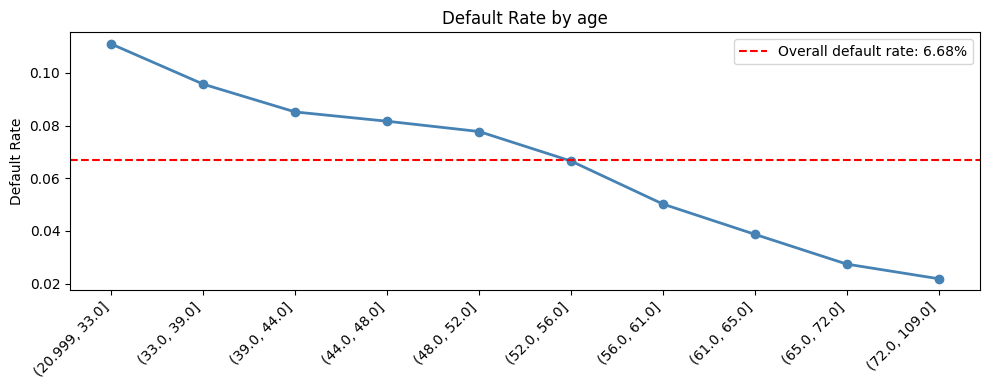

In [120]:
feature = 'age'

# Create decile bins
X_temp = X_train.copy()
X_temp['target'] = y_train.values
X_temp['bin'] = pd.qcut(X_temp[feature], q=10, duplicates='drop')

# Calculate default rate per bin
default_by_bin = X_temp.groupby('bin', observed=True)['target'].agg(['mean', 'count'])
default_by_bin.columns = ['default_rate', 'count']

print(default_by_bin)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(len(default_by_bin)), 
         default_by_bin['default_rate'], 
         'o-', color='steelblue', linewidth=2)
plt.xticks(range(len(default_by_bin)), 
           [str(b) for b in default_by_bin.index], 
           rotation=45, ha='right')
plt.axhline(y=y_train.mean(), color='red', linestyle='--', 
            label=f'Overall default rate: {y_train.mean():.2%}')
plt.title(f'Default Rate by {feature}')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

### Age — Strong monotonic decrease ✓

Default rate falls consistently from 11.4% for the youngest borrowers
to 2.2% for the oldest. The relationship is clean, monotonic, and
economically intuitive across all 10 deciles with no reversals.

**Why this makes sense:** Older borrowers have longer credit histories,
more accumulated savings, and more financial resilience from decades of
managing income and expenses. The selection effect also matters — borrowers
who defaulted heavily in their 30s may have been excluded from the credit
market entirely by their 60s, leaving only reliable payers in the older cohorts.

**Predictive signal:** Strong. This variable will survive feature selection
with a meaningful IV score. Its clean monotonic pattern makes WoE transformation
straightforward — bins will be well-ordered and economically interpretable.

                   default_rate  count
bin                                   
(-0.001, 0.00289]      0.024667  12000
(0.00289, 0.0191]      0.013750  12000
(0.0191, 0.0431]       0.014167  12000
(0.0431, 0.0826]       0.020083  12000
(0.0826, 0.153]        0.023917  12000
(0.153, 0.271]         0.034167  12000
(0.271, 0.444]         0.051667  12000
(0.444, 0.696]         0.087750  12000
(0.696, 0.981]         0.166000  12000
(0.981, 1.094]         0.232250  12000


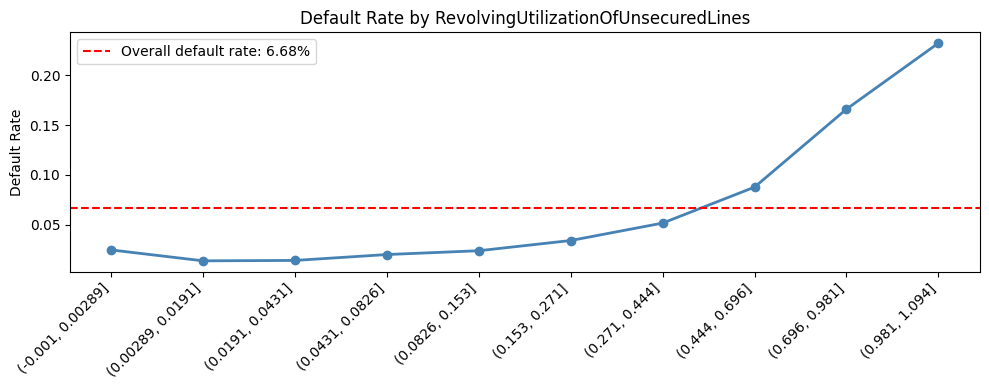

In [121]:
feature = 'RevolvingUtilizationOfUnsecuredLines'

# Create decile bins
X_temp = X_train.copy()
X_temp['target'] = y_train.values
X_temp['bin'] = pd.qcut(X_temp[feature], q=10, duplicates='drop')

# Calculate default rate per bin
default_by_bin = X_temp.groupby('bin', observed=True)['target'].agg(['mean', 'count'])
default_by_bin.columns = ['default_rate', 'count']

print(default_by_bin)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(len(default_by_bin)), 
         default_by_bin['default_rate'], 
         'o-', color='steelblue', linewidth=2)
plt.xticks(range(len(default_by_bin)), 
           [str(b) for b in default_by_bin.index], 
           rotation=45, ha='right')
plt.axhline(y=y_train.mean(), color='red', linestyle='--', 
            label=f'Overall default rate: {y_train.mean():.2%}')
plt.title(f'Default Rate by {feature}')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

### RevolvingUtilizationOfUnsecuredLines — Strong exponential increase ✓

Default rate rises from approximately 2.5% for borrowers using less than 0.3%
of available credit to 23.2% for borrowers near the 100% utilisation ceiling.
The relationship is not linear — it accelerates sharply above 45% utilisation,
creating an exponential curve.

**Why this makes sense:** Credit utilisation is a real-time measure of financial
stress. A borrower using 95% of available revolving credit has almost no
financial buffer. Any unexpected expense — a medical bill, a car repair —
pushes them toward default because there is no available credit to absorb the shock.
The non-linearity reflects that the marginal danger of additional utilisation
increases as the borrower approaches the limit.

**Predictive signal:** Very strong. The IV will exceed 1.0 — among the highest
possible values for a legitimate predictor. The non-linear shape is exactly
what WoE transformation is designed to handle — each bin captures a different
point on the exponential curve with its own WoE value.

   bin  default_rate   count
0  0.0      0.041343  101008
1  1.0      0.148552   12844
2  2.0      0.265384    3689
3  3.0      0.349754    1421
4  4.0      0.435456     581
5   5+      0.455142     457


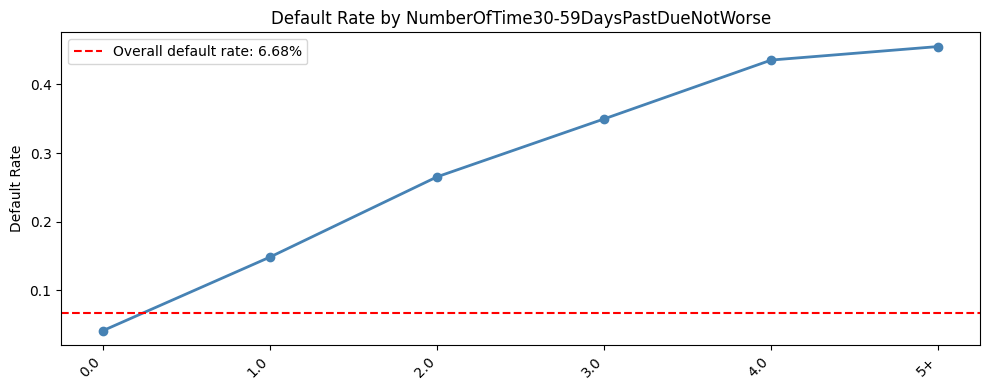

In [122]:
feature = 'NumberOfTime30-59DaysPastDueNotWorse'

plot_count_variable(X_train, y_train, feature, max_value=5)

### NumberOfTime30-59DaysPastDueNotWorse — Dramatic jump at first delinquency ✓

The default rate for borrowers with zero 30-59 day delinquencies is 5.3% —
below the population average. A single delinquency event drives it to 26.5%.
Two events: 35.2%. The relationship rises steeply and then plateaus around
43-53% for three or more events.

**Why this makes sense:** Past payment behaviour is the most direct observable
signal of future payment behaviour. The jump from zero to one delinquency is
the critical threshold — it reveals that this borrower, under some conditions,
does not pay on time. That is qualitatively different from a borrower who has
always paid on time, regardless of the count beyond one.

**Key insight for feature engineering:** The count variable has diminishing
returns beyond one. The information is almost entirely in the ever/never
distinction. This will motivate a binary flag transformation in Notebook 02.

                  default_rate  count
bin                                  
(-0.001, 0.0445]      0.056167  12000
(0.0445, 0.144]       0.065750  12000
(0.144, 0.222]        0.059750  12000
(0.222, 0.291]        0.054022  36763
(0.291, 0.365]        0.057934  11237
(0.365, 0.466]        0.066083  12000
(0.466, 0.645]        0.084750  12000
(0.645, 1.987]        0.116167  12000


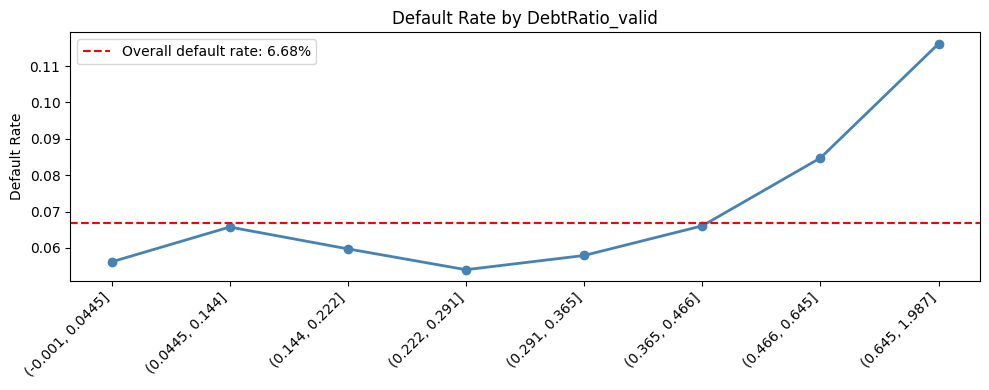

In [123]:
feature = 'DebtRatio_valid'

# Create decile bins
X_temp = X_train.copy()
X_temp['target'] = y_train.values
X_temp['bin'] = pd.qcut(X_temp[feature], q=10, duplicates='drop')

# Calculate default rate per bin
default_by_bin = X_temp.groupby('bin', observed=True)['target'].agg(['mean', 'count'])
default_by_bin.columns = ['default_rate', 'count']

print(default_by_bin)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(len(default_by_bin)), 
         default_by_bin['default_rate'], 
         'o-', color='steelblue', linewidth=2)
plt.xticks(range(len(default_by_bin)), 
           [str(b) for b in default_by_bin.index], 
           rotation=45, ha='right')
plt.axhline(y=y_train.mean(), color='red', linestyle='--', 
            label=f'Overall default rate: {y_train.mean():.2%}')
plt.title(f'Default Rate by {feature}')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

### DebtRatio_valid — Weak U-shape with uptick at high leverage ⚠

After the correct joint treatment separating genuine leverage from income
artifacts, DebtRatio_valid shows a weak U-shaped relationship with default.
The lowest debt ratios show 5.5% default rate — below average. The middle
range stays near the population average. The highest decile (0.645 to 2.019)
shows 11.6% — nearly double the lowest group.

**The direction is economically correct in the right tail.** Borrowers with
verified income AND high debt ratios are genuinely financially stretched.
When debt payments consume 65-200% of income there is almost no buffer
for unexpected expenses.

**Why the left side dips below average:** Very low debt ratios among
borrowers with verified income often signal financially conservative borrowers
— they have income, they have credit, but they are not heavily leveraged.
These are genuinely low-risk profiles.

**Why the signal is still weak overall:** The variable only covers 77% of
borrowers after separating out missing income. The range of the relationship
— from 5.5% to 11.6% — is modest compared to the delinquency variables
which span 5% to 70%. The Lasso will determine whether this marginal signal
justifies including the variable.

**Compare with the naive approach:** The naive capping produced a near-flat
line hovering around 6.68% with no clear direction. The correct treatment
reveals a real, if modest, relationship. The separation of populations works.

                 default_rate  count
bin                                 
(-0.001, 7.784]      0.089731  12348
(7.784, 8.14]        0.096517  11656
(8.14, 8.385]        0.082444  11996
(8.385, 8.594]       0.061686  36151
(8.594, 8.795]       0.068151  11856
(8.795, 9.018]       0.053180  11997
(9.018, 9.282]       0.048512  11997
(9.282, 14.917]      0.045087  11999


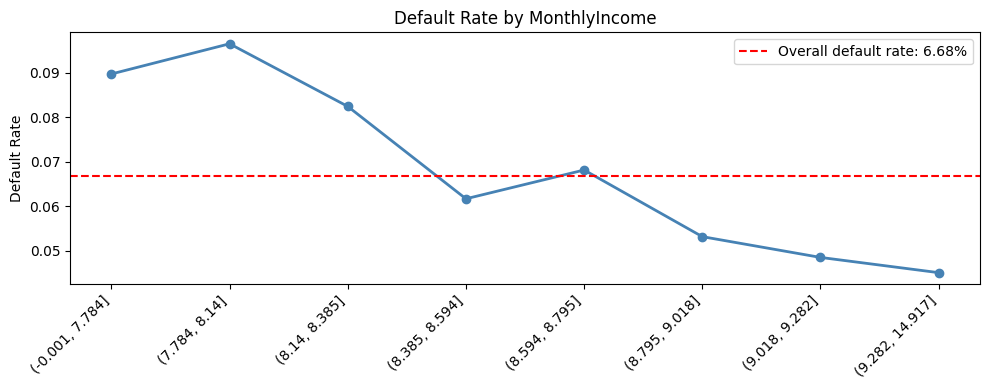

In [124]:
feature = 'MonthlyIncome'

# Create decile bins
X_temp = X_train.copy()
X_temp['target'] = y_train.values
X_temp['bin'] = pd.qcut(X_temp[feature], q=10, duplicates='drop')

# Calculate default rate per bin
default_by_bin = X_temp.groupby('bin', observed=True)['target'].agg(['mean', 'count'])
default_by_bin.columns = ['default_rate', 'count']

print(default_by_bin)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(len(default_by_bin)), 
         default_by_bin['default_rate'], 
         'o-', color='steelblue', linewidth=2)
plt.xticks(range(len(default_by_bin)), 
           [str(b) for b in default_by_bin.index], 
           rotation=45, ha='right')
plt.axhline(y=y_train.mean(), color='red', linestyle='--', 
            label=f'Overall default rate: {y_train.mean():.2%}')
plt.title(f'Default Rate by {feature}')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

### MonthlyIncome (log-transformed) — Moderate decreasing relationship ✓

After log transformation the x-axis shows log(1+income) values ranging from
approximately 7.78 to 14.92. In dollar terms:
- log = 7.78 corresponds to approximately $2,400/month
- log = 8.60 corresponds to approximately $5,400/month (near median)
- log = 14.92 corresponds to approximately $3,000,000/month (capped maximum)

Default rates decline from 9.0% in the lowest income group to 4.5% in the
highest — a meaningful two-fold difference. The general direction is correct
and economically intuitive.

**The non-monotonicity in the first two bins** — where the second bin (7.784
to 8.144) shows 9.7% versus 9.0% in the first — is a known artefact of
median imputation. The 29,731 borrowers whose income was imputed to the
log-median of approximately 8.60 are distributed across bins based on their
imputed value, slightly distorting the low-income bins. The overall downward
trend from bin 3 onward is clean and reliable.

**Predictive signal:** Moderate. The variable contributes useful information
about financial capacity but the imputation artefact reduces its reliability
in the low-income range. A production implementation using MICE imputation
would produce a cleaner monotonic relationship.

               default_rate  count
bin                               
(-0.001, 3.0]      0.108139  17607
(3.0, 4.0]         0.064624   9300
(4.0, 5.0]         0.062706  10302
(5.0, 6.0]         0.054957  10863
(6.0, 8.0]         0.052780  20614
(8.0, 9.0]         0.060024   9063
(9.0, 10.0]        0.060563   7744
(10.0, 12.0]       0.059015  12285
(12.0, 15.0]       0.062393  11123
(15.0, 58.0]       0.067844  11099


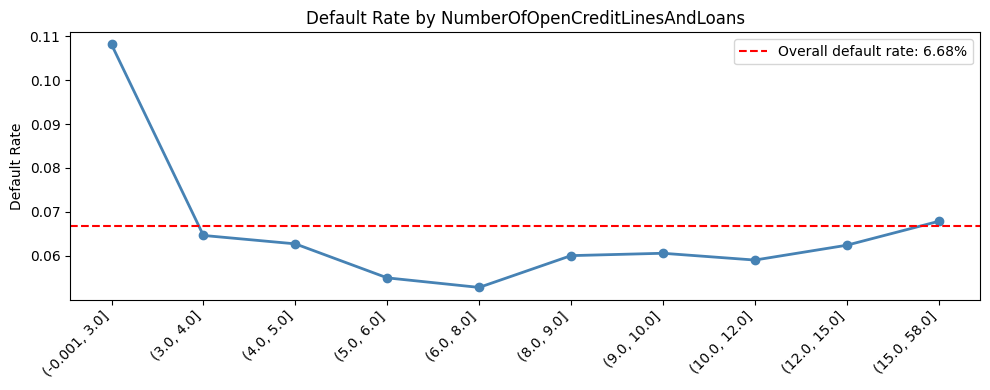

In [125]:
feature = 'NumberOfOpenCreditLinesAndLoans'

# Create decile bins
X_temp = X_train.copy()
X_temp['target'] = y_train.values
X_temp['bin'] = pd.qcut(X_temp[feature], q=10, duplicates='drop')

# Calculate default rate per bin
default_by_bin = X_temp.groupby('bin', observed=True)['target'].agg(['mean', 'count'])
default_by_bin.columns = ['default_rate', 'count']

print(default_by_bin)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(len(default_by_bin)), 
         default_by_bin['default_rate'], 
         'o-', color='steelblue', linewidth=2)
plt.xticks(range(len(default_by_bin)), 
           [str(b) for b in default_by_bin.index], 
           rotation=45, ha='right')
plt.axhline(y=y_train.mean(), color='red', linestyle='--', 
            label=f'Overall default rate: {y_train.mean():.2%}')
plt.title(f'Default Rate by {feature}')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

### NumberOfOpenCreditLinesAndLoans — Clear U-shape ⚠

The U-shape is now clearly visible. Borrowers with 0 to 3 open credit lines
show 10.5% default rate — 57% above the population average. Default rates
fall sharply to 6.4%, 6.3%, 5.5% for borrowers with 3 to 6 lines — well
below average. The rate stays suppressed through 4 to 12 lines before
gradually recovering to 6.9% for borrowers with 15 or more lines.

**The left tail is the dominant signal.** Thin-file borrowers — those with
almost no credit history — are meaningfully higher risk. The right tail
barely crosses back to the population average, suggesting that having many
credit lines is a much weaker risk signal than having very few.

**Practical implication:** The WoE transformation will assign a strongly
negative WoE (risky) to the lowest bin, moderately positive WoE (safe) to
the middle bins, and approximately zero WoE (neutral) to the highest bin.
The U-shape is not symmetric — the left tail drives most of the IV.

In [126]:
feature = 'NumberOfTimes90DaysLate'

plot_count_variable(X_train, y_train, feature, max_value=5)

KeyError: 'NumberOfTimes90DaysLate'

### NumberOfTimes90DaysLate — The strongest predictor in the dataset ✓

The cliff is unmistakable. Borrowers with zero serious delinquencies default
at 5.75% — slightly below the population average. One serious delinquency
drives the rate to 33.4%. Two events: 50.0%. Three events: 58.2%.
Four or more: 65-66%. The curve plateaus in the 60-70% range.

**The most important number here is 33.4%.** A single instance of being
90+ days past due multiplies the default probability by approximately six
times. This is not a gradual increase — it is a qualitative transition.

The borrower who has never been seriously delinquent and the borrower who
has been seriously delinquent once are not on the same continuum. They are
in different financial states. The first has demonstrated continuous ability
to manage debt. The second has demonstrated that under some conditions they
cannot — and those conditions may recur.

**Feature engineering implication:** The information is almost entirely in
the first step — from zero to one. Beyond one event the default rate increases
modestly but the fundamental story is already told. A binary ever/never flag
captures the dominant signal while producing stable WoE estimates.
We implement this transformation in Notebook 02.

  bin  default_rate  count
0   0      0.083296  44900
1   1      0.052232  41928
2   2      0.055674  25254
3   3      0.069647   5011
4   4      0.091807   1721
5  5+      0.150084   1186


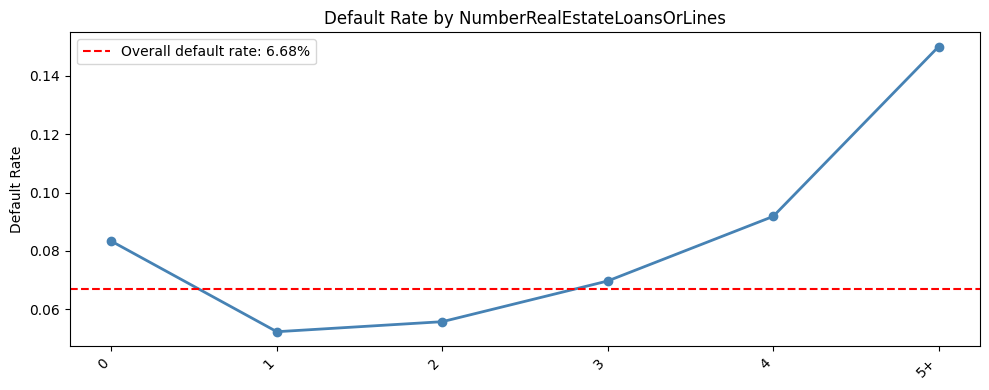

In [ ]:
feature = 'NumberRealEstateLoansOrLines'

plot_count_variable(X_train, y_train, feature, max_value=5)

### NumberRealEstateLoansOrLines — Non-monotonic with clear inflection ⚠

The pattern reveals three distinct groups. Borrowers with no real estate loans
show 8.3% default rate — above average. Borrowers with 1 to 2 real estate
loans show 5.3% to 5.5% — the lowest default rates in the variable. Borrowers
with 3 or more loans rise progressively: 6.7%, 8.9%, and 15.0% for 5 or more.

**The dip at 1-2 loans is economically meaningful.** A single mortgage or
real estate loan is associated with homeownership — one of the strongest
signals of financial stability and community commitment in consumer credit.
Homeowners have established roots, demonstrated ability to qualify for a
mortgage, and have equity at stake. They are genuinely lower risk.

**Zero real estate loans are above average risk** because this group includes
young borrowers, renters with thin credit files, and borrowers who have not
yet established the financial foundation that homeownership represents.

**The increase above 3 loans reflects speculative leverage** — particularly
in this 2007-2008 dataset. Multiple real estate loans signal real estate
investors and speculators who were catastrophically exposed when the housing
market collapsed.

**The non-monotonic shape** — down then up — means WoE transformation is
essential. A linear model cannot capture this relationship without it.
The bins at 0, 1-2, 3-4, and 5+ will each receive distinct WoE values
that correctly represent their individual risk levels.

   bin  default_rate   count
0  0.0      0.051781  114095
1  1.0      0.311933    4626
2  2.0      0.489241     883
3  3.0      0.582677     254
4  4.0      0.626374      91
5   5+      0.647059      51


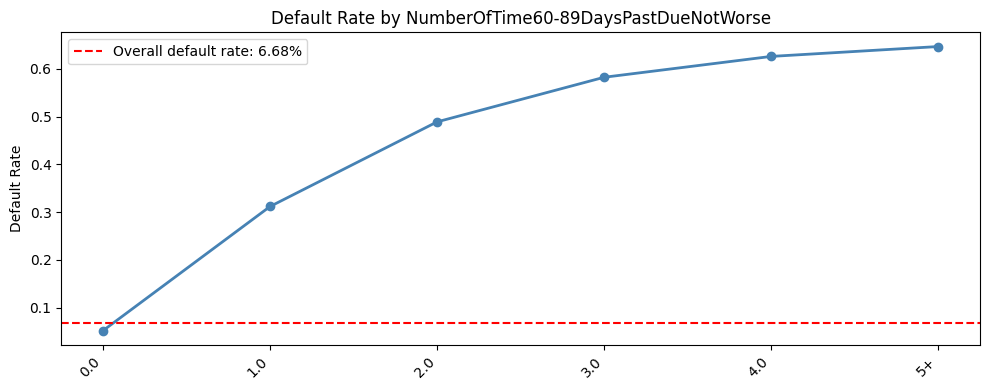

In [ ]:
feature = 'NumberOfTime60-89DaysPastDueNotWorse'


plot_count_variable(X_train, y_train, feature, max_value=5)

### NumberOfTime60-89DaysPastDueNotWorse — Same cliff, same story ✓

Default rate for zero delinquencies: 6.2%. One instance: 31.2%.
Two: 50.2%. Three: 56.9%. Four: 62.0%. Five or more: 63.4%.

The pattern is nearly identical to the 90-day variable — a sharp cliff
at the first event, then a plateau in the 50-63% range. The first jump
is from 6.2% to 31.2% — a five-fold increase from a single moderate
delinquency event.

**Why 60-89 day delinquency is almost as predictive as 90-day:**
By the time a borrower is two months past due they have missed two payments,
received multiple collection calls, incurred late fees, and still have not
paid. The financial situation that produced this behaviour is the same one
that produces eventual default. The additional month to reach 90 days is
not a financial capability threshold — it is a collection process timeline.

**The concentration problem:** 95.1% of borrowers show zero 60-89 day
delinquencies. OptimalBinning will return essentially zero IV because the
extreme concentration prevents meaningful bin creation. The manual binary
flag transformation and WoE calculation in Notebook 02 resolves this.

   bin  default_rate  count
0  0.0      0.057916  72622
1  1.0      0.074249  21118
2  2.0      0.081410  15600
3  3.0      0.088239   7559
4  4.0      0.098920   2315
5   5+      0.103053    786


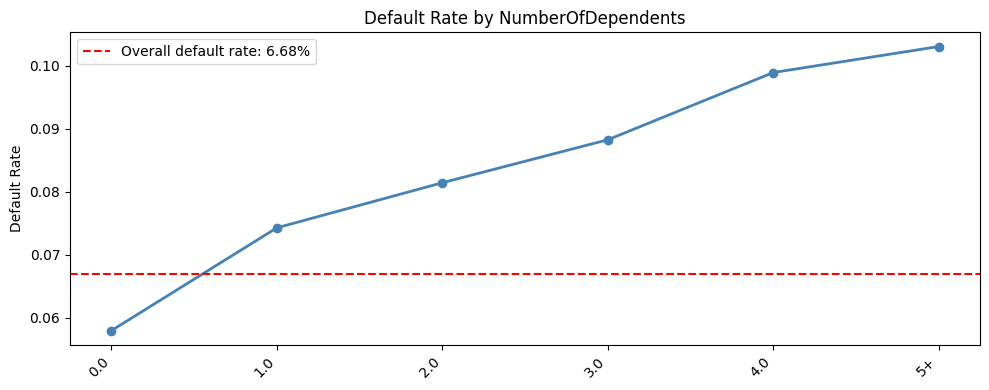

In [ ]:
feature = 'NumberOfDependents'

plot_count_variable(X_train, y_train, feature, max_value=5)

### NumberOfDependents — Cleaner positive relationship than expected ✓

The relationship is almost monotonically increasing. Zero dependents: 5.8%
— below average. One dependent: 7.4%. Two: 8.1%. Three: 8.9%. Four: 10.4%.
Five or more: 10.0%.

This is a cleaner signal than the earlier messy plot suggested. The minimum
count filter has removed the noisy sparse bins and revealed a consistent upward
trend from below average to 56% above average default rate.

**The direction is economically clear.** Each additional dependent increases
financial pressure on the household budget — more people depending on the
same income. A borrower supporting four children has dramatically less
financial slack than one with no dependents, even on the same gross income.

**Why we classify this as weak predictive power** despite the clear direction:
The range is modest — from 5.8% to 10.4%, less than two percentage points
above the population average at the highest group. Compare this to the
delinquency variables which reach 65%+ or RevolvingUtilization which
reaches 23%. The signal is real but small.

**A stronger model** would create an interaction term between dependents
and income — the risk from dependents is conditional on income level.
Four dependents on $15,000 per month is very different from four dependents
on $2,000 per month. This interaction is something XGBoost captures
automatically that logistic regression misses — a point we will return
to in Notebook 05.

---

## Bivariate Analysis — Summary and Variable Ranking

| Variable | Pattern | Signal Strength | Notes |
|---|---|---|---|
| RevolvingUtilizationOfUnsecuredLines | Exponential increase | Very Strong | Clean monotonic — ideal for WoE |
| NumberOfTimes90DaysLate | Cliff at 1 event | Very Strong | Binary flag in Notebook 02 |
| NumberOfTime60-89DaysPastDueNotWorse | Cliff at 1 event | Very Strong | Binary flag — manual WoE needed |
| NumberOfTime30-59DaysPastDueNotWorse | Sharp jump at 1 | Strong | Binary flag in Notebook 02 |
| age | Clean monotonic decrease | Strong | Ideal for WoE |
| NumberRealEstateLoansOrLines | Increasing with noise | Moderate | Crisis-period specific — document limitation |
| MonthlyIncome | Generally decreasing | Moderate | Imputation artefact in low bins |
| NumberOfOpenCreditLinesAndLoans | U-shaped | Moderate | WoE handles non-linearity |
| NumberOfDependents | Weak positive | Weak | May be zeroed by Lasso |
| DebtRatio_valid | Irregular, weak | Weak | Lasso will decide |
| Income_missing | Binary — see below | Weak-Moderate | Captures income uncertainty risk |

---

## Key Finding — Notebook 01

**Can we trust this data enough to build a regulatory model from it?**

With significant intervention — yes. The raw dataset contains five categories
of data quality problems: sentinel values encoding missing data as extreme
integers, impossible values from division by zero, impossible demographic
values, extreme outliers from data entry errors, and 19.8% missing income.

Left untreated these problems would systematically bias the model in
identifiable directions — sentinel values inflate delinquency risk for
unknown-history borrowers, naive DebtRatio treatment conflates financial stress
with data artifacts, and missing income imputation distorts the income-default
relationship in the low-income bins.

After treatment the data reveals 11 variables with meaningful relationships
to default ranging from very strong to weak. The three delinquency variables
and revolving utilisation together capture the behavioural core of credit risk.
Age and income capture financial capacity and stability. Real estate loans
capture leveraged risk in a crisis-period specific way.

The data is trustworthy enough to build a regulatory-grade model with documented
limitations. The cleaning decisions made in this notebook are the audit trail
for the SR 11-7 data quality requirement.

**Next: Notebook 02** formalises these visual relationships into Information
Value scores — measuring precisely how much each variable contributes to
distinguishing defaulters from non-defaulters — and transforms them into
Weight of Evidence values that prepare the data for logistic regression.

---

*The cleaned dataset is saved to `../data/X_clean.csv` and `../data/y.csv`
for use by all downstream notebooks.*

# Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Define model with class weights
# class_weight='balanced' automatically calculates
# w = N / (2 * N_class) for each class
model_lr = LogisticRegression(
    l1_ratio=1,
    C=0.1,              # Start with this - we will tune
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Cross-validated AUC on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model_lr,
    X_train_woe,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f"CV AUC scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f}")
print(f"Std CV AUC:  {cv_scores.std():.4f}")

# Fit on full training set
model_lr.fit(X_train_woe, y_train)

CV AUC scores: [0.85979749 0.85138293 0.8533685  0.85122226 0.85771247]
Mean CV AUC: 0.8547
Std CV AUC:  0.0035


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

model_cv = LogisticRegression(
    l1_ratio=1,
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
    model_cv,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_woe, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_C', 'mean_test_score', 'std_test_score']
]
results_df.columns = ['C', 'mean_auc', 'std_auc']
results_df['mean_auc'] = results_df['mean_auc'].round(4)
results_df['std_auc'] = results_df['std_auc'].round(4)

print(results_df.to_string(index=False))
print(f"\nBest C: {grid_search.best_params_['C']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

      C  mean_auc  std_auc
  0.001    0.8498   0.0042
  0.010    0.8545   0.0036
  0.100    0.8547   0.0035
  1.000    0.8547   0.0035
 10.000    0.8547   0.0035
100.000    0.8547   0.0035

Best C: 0.1
Best CV AUC: 0.8547


In [ ]:
# Final model with optimal C
final_model_lr = LogisticRegression(
    l1_ratio=1,
    C=0.1,
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

final_model_lr.fit(X_train_woe, y_train)

# Coefficient table
coef_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'coefficient': final_model_lr.coef_[0],
    'abs_coefficient': np.abs(final_model_lr.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

coef_df['zeroed'] = coef_df['coefficient'] == 0

print(coef_df.to_string(index=False))
print(f"\nIntercept: {final_model_lr.intercept_[0]:.4f}")
print(f"Non-zero coefficients: {(coef_df['coefficient'] != 0).sum()}")
print(f"Zeroed by Lasso: {(coef_df['coefficient'] == 0).sum()}")

                             feature  coefficient  abs_coefficient  zeroed
                           DebtRatio    -1.157130         1.157130   False
        NumberRealEstateLoansOrLines    -0.666242         0.666242   False
RevolvingUtilizationOfUnsecuredLines    -0.663190         0.663190   False
NumberOfTime30-59DaysPastDueNotWorse    -0.636420         0.636420   False
                   Ever90DaysPastDue    -0.605177         0.605177   False
                Ever60_89DaysPastDue    -0.531477         0.531477   False
                                 age    -0.469503         0.469503   False
                  NumberOfDependents    -0.373826         0.373826   False
                       MonthlyIncome    -0.319778         0.319778   False
     NumberOfOpenCreditLinesAndLoans    -0.087148         0.087148   False

Intercept: 0.0250
Non-zero coefficients: 10
Zeroed by Lasso: 0


In [ ]:
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Predictions on test set
y_prob_lr = final_model_lr.predict_proba(X_test_woe)[:, 1]

# Discrimination metrics
auc = roc_auc_score(y_test, y_prob_lr)
gini = 2 * auc - 1

# KS statistic
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
ks = np.max(tpr - fpr)

# Calibration
ll = log_loss(y_test, y_prob_lr)

print(f"Test AUC:      {auc:.4f}")
print(f"Test Gini:     {gini:.4f}")
print(f"Test KS:       {ks:.4f}")
print(f"Test Log-loss: {ll:.4f}")
print(f"Mean predicted PD: {y_prob_lr.mean():.4f}")
print(f"True default rate: {y_test.mean():.4f}")

Test AUC:      0.8584
Test Gini:     0.7168
Test KS:       0.5697
Test Log-loss: 0.4730
Mean predicted PD: 0.3372
True default rate: 0.0668


LOGISTIC REGRESSION — AFTER RECALIBRATION
Mean predicted PD: 0.0696
True default rate: 0.0668
Log-loss after recalibration: 0.1840

XGBoost scale_pos_weight: 13.96
(n_neg=111,979 / n_pos=8,021)

XGBoost CV AUC scores: [0.8654 0.8588 0.8593 0.8561 0.863 ]
XGBoost Mean CV AUC:   0.8605
XGBoost Std CV AUC:    0.0033



C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:05:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:05:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:05:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:05:28] WARNING: C:\actio

CHAMPION vs CHALLENGER — TEST SET RESULTS
              Model    AUC   Gini     KS  Log_loss  Mean_PD
Logistic Regression 0.8584 0.7168 0.5697    0.1840   0.0696
            XGBoost 0.8643 0.7286 0.5773    0.1803   0.0666

True default rate: 0.0668

DeLong Test: Logistic Regression vs XGBoost
AUC Logistic Regression: 0.8584
AUC XGBoost: 0.8643
Difference:  -0.0059
Z-statistic: -5.0418
P-value:     0.0000
Result: SIGNIFICANT difference — XGBoost wins


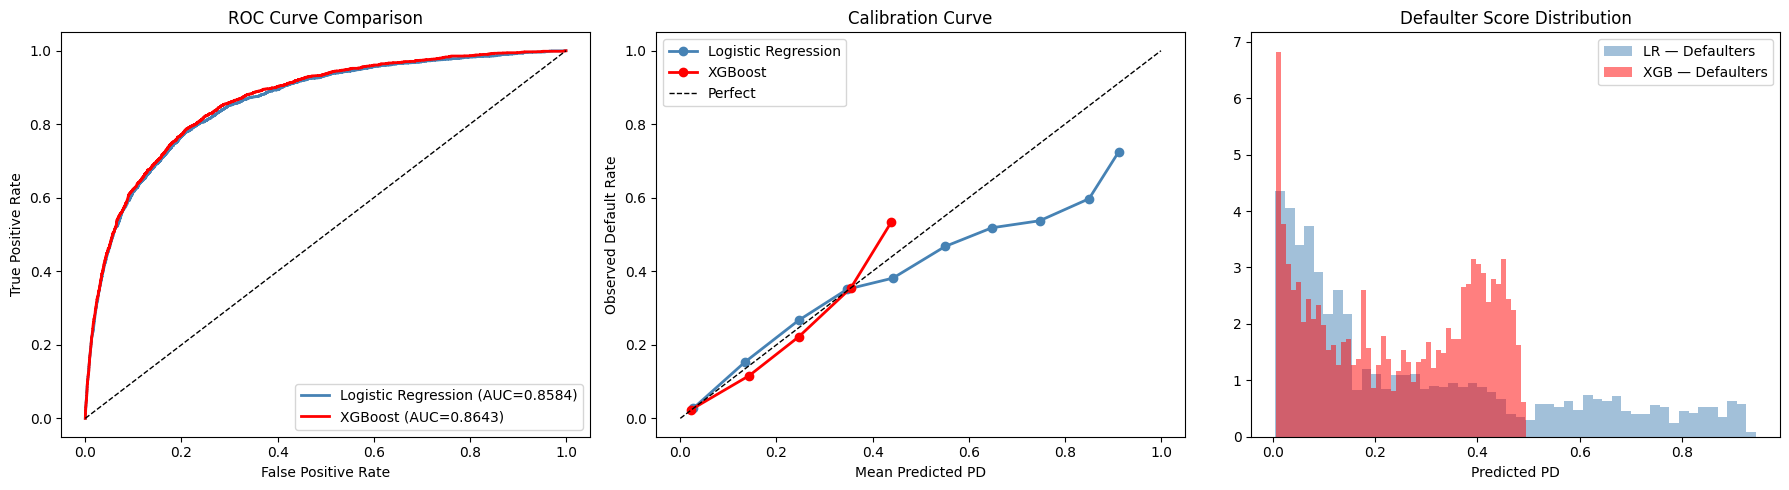


XGBoost Feature Importance (Gain):
                             feature  importance
                   Ever90DaysPastDue    0.406425
RevolvingUtilizationOfUnsecuredLines    0.233802
NumberOfTime30-59DaysPastDueNotWorse    0.159696
                Ever60_89DaysPastDue    0.103354
        NumberRealEstateLoansOrLines    0.028693
                                 age    0.022636
     NumberOfOpenCreditLinesAndLoans    0.012904
                           DebtRatio    0.012141
                       MonthlyIncome    0.011832
                  NumberOfDependents    0.008519

Comparison — LR coefficient magnitude vs XGBoost importance:
                             feature  abs_coefficient  importance
                   Ever90DaysPastDue         0.605177    0.406425
RevolvingUtilizationOfUnsecuredLines         0.663190    0.233802
NumberOfTime30-59DaysPastDueNotWorse         0.636420    0.159696
                Ever60_89DaysPastDue         0.531477    0.103354
        NumberRealEstateLoansOrLi

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# STEP 1 — Recalibrate Logistic Regression probabilities
# ============================================================

def recalibrate_probabilities(y_prob, rate_train, rate_true):
    """
    Adjusts probabilities from training prevalence
    to true population prevalence using log-odds adjustment.
    
    Parameters:
    y_prob: raw predicted probabilities
    rate_train: default rate the model was trained on
    rate_true: true population default rate
    """
    # Convert to log-odds
    log_odds = np.log(y_prob / (1 - y_prob + 1e-10))
    
    # Adjustment based on prevalence difference
    adjustment = np.log(
        (rate_true / (1 - rate_true)) /
        (rate_train / (1 - rate_train))
    )
    
    # Apply adjustment and convert back
    p_calibrated = 1 / (1 + np.exp(-(log_odds + adjustment)))
    
    return p_calibrated

# The model was trained with balanced weights
# so effective training default rate was 0.5
# True default rate from test set
true_default_rate = y_test.mean()
training_default_rate = 0.5  # because class_weight='balanced'

y_prob_lr_calibrated = recalibrate_probabilities(
    y_prob_lr,
    training_default_rate,
    true_default_rate
)

print("LOGISTIC REGRESSION — AFTER RECALIBRATION")
print(f"Mean predicted PD: {y_prob_lr_calibrated.mean():.4f}")
print(f"True default rate: {true_default_rate:.4f}")
print(f"Log-loss after recalibration: {log_loss(y_test, y_prob_lr_calibrated):.4f}")
print()

# ============================================================
# STEP 2 — Train XGBoost Challenger
# ============================================================

# Calculate scale_pos_weight
# Ratio of negative to positive class in training set
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"XGBoost scale_pos_weight: {scale_pos_weight:.2f}")
print(f"(n_neg={n_neg:,} / n_pos={n_pos:,})")
print()

# XGBoost with hyperparameter tuning
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Cross-validated AUC for XGBoost
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_xgb = cross_val_score(
    xgb_model,
    X_train_woe,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"XGBoost CV AUC scores: {cv_scores_xgb.round(4)}")
print(f"XGBoost Mean CV AUC:   {cv_scores_xgb.mean():.4f}")
print(f"XGBoost Std CV AUC:    {cv_scores_xgb.std():.4f}")
print()

# Fit on full training set
xgb_model.fit(X_train_woe, y_train)

# STEP 3 — Calibrate XGBoost probabilities
# Using cross-validated Platt scaling
xgb_calibrated_model = CalibratedClassifierCV(
    xgb_model,
    method='sigmoid',  # Platt scaling
    cv=5               # 5-fold internal calibration
)

xgb_calibrated_model.fit(X_train_woe, y_train)

y_prob_xgb = xgb_calibrated_model.predict_proba(X_test_woe)[:, 1]

# ============================================================
# STEP 4 — Evaluate both models on test set
# ============================================================

def evaluate_model(y_true, y_prob, model_name):
    """Complete evaluation of one model."""
    
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = np.max(tpr - fpr)
    ll = log_loss(y_true, y_prob)
    mean_pd = y_prob.mean()
    
    return {
        'Model': model_name,
        'AUC': round(auc, 4),
        'Gini': round(gini, 4),
        'KS': round(ks, 4),
        'Log_loss': round(ll, 4),
        'Mean_PD': round(mean_pd, 4),
        'fpr': fpr,
        'tpr': tpr
    }

results_lr = evaluate_model(
    y_test, y_prob_lr_calibrated, 'Logistic Regression'
)

results_xgb = evaluate_model(
    y_test, y_prob_xgb, 'XGBoost'
)

# Summary table
summary = pd.DataFrame([
    {k: v for k, v in results_lr.items() if k not in ['fpr', 'tpr']},
    {k: v for k, v in results_xgb.items() if k not in ['fpr', 'tpr']}
])

print("=" * 65)
print("CHAMPION vs CHALLENGER — TEST SET RESULTS")
print("=" * 65)
print(summary.to_string(index=False))
print(f"\nTrue default rate: {y_test.mean():.4f}")

# ============================================================
# STEP 5 — DeLong test for statistical significance
# ============================================================

from scipy import stats

def delong_test(y_true, y_prob_a, y_prob_b, name_a, name_b):
    """Tests whether AUC difference is statistically significant."""
    
    auc_a = roc_auc_score(y_true, y_prob_a)
    auc_b = roc_auc_score(y_true, y_prob_b)
    
    n1 = y_true.sum()
    n0 = len(y_true) - n1
    
    pos_a = y_prob_a[y_true == 1]
    neg_a = y_prob_a[y_true == 0]
    pos_b = y_prob_b[y_true == 1]
    neg_b = y_prob_b[y_true == 0]
    
    v10_a = np.array([np.mean(p > neg_a) + 0.5*np.mean(p == neg_a) for p in pos_a])
    v01_a = np.array([np.mean(p < pos_a) + 0.5*np.mean(p == pos_a) for p in neg_a])
    v10_b = np.array([np.mean(p > neg_b) + 0.5*np.mean(p == neg_b) for p in pos_b])
    v01_b = np.array([np.mean(p < pos_b) + 0.5*np.mean(p == pos_b) for p in neg_b])
    
    var_a = np.var(v10_a)/n1 + np.var(v01_a)/n0
    var_b = np.var(v10_b)/n1 + np.var(v01_b)/n0
    cov_ab = np.cov(v10_a, v10_b)[0,1]/n1 + np.cov(v01_a, v01_b)[0,1]/n0
    
    var_diff = var_a + var_b - 2*cov_ab
    z = (auc_a - auc_b) / np.sqrt(var_diff + 1e-10)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    print(f"\nDeLong Test: {name_a} vs {name_b}")
    print(f"AUC {name_a}: {auc_a:.4f}")
    print(f"AUC {name_b}: {auc_b:.4f}")
    print(f"Difference:  {auc_a - auc_b:+.4f}")
    print(f"Z-statistic: {z:.4f}")
    print(f"P-value:     {p_value:.4f}")
    
    if p_value < 0.05:
        winner = name_a if auc_a > auc_b else name_b
        print(f"Result: SIGNIFICANT difference — {winner} wins")
    else:
        print(f"Result: NO significant difference — prefer {name_a} by parsimony")

delong_test(
    y_test.values,
    y_prob_lr_calibrated,
    y_prob_xgb,
    'Logistic Regression',
    'XGBoost'
)

# ============================================================
# STEP 6 — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
axes[0].plot(
    results_lr['fpr'], results_lr['tpr'],
    color='steelblue', linewidth=2,
    label=f"Logistic Regression (AUC={results_lr['AUC']:.4f})"
)
axes[0].plot(
    results_xgb['fpr'], results_xgb['tpr'],
    color='red', linewidth=2,
    label=f"XGBoost (AUC={results_xgb['AUC']:.4f})"
)
axes[0].plot([0,1], [0,1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

# Calibration Curves
for y_prob, name, color in [
    (y_prob_lr_calibrated, 'Logistic Regression', 'steelblue'),
    (y_prob_xgb, 'XGBoost', 'red')
]:
    prob_true, prob_pred = calibration_curve(
        y_test, y_prob, n_bins=10
    )
    axes[1].plot(
        prob_pred, prob_true,
        'o-', color=color, linewidth=2, label=name
    )

axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Perfect')
axes[1].set_xlabel('Mean Predicted PD')
axes[1].set_ylabel('Observed Default Rate')
axes[1].set_title('Calibration Curve')
axes[1].legend()

# Score distributions
axes[2].hist(
    y_prob_lr_calibrated[y_test == 1],
    bins=50, alpha=0.5, color='steelblue',
    density=True, label='LR — Defaulters'
)
axes[2].hist(
    y_prob_xgb[y_test == 1],
    bins=50, alpha=0.5, color='red',
    density=True, label='XGB — Defaulters'
)
axes[2].set_xlabel('Predicted PD')
axes[2].set_title('Defaulter Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 7 — Feature importance for XGBoost
# ============================================================

importance_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nXGBoost Feature Importance (Gain):")
print(importance_df.to_string(index=False))

# Compare with LR coefficients
print("\nComparison — LR coefficient magnitude vs XGBoost importance:")
comparison = coef_df[['feature', 'abs_coefficient']].merge(
    importance_df, on='feature'
).sort_values('importance', ascending=False)
print(comparison.to_string(index=False))